In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score



In [3]:
print("TASK 1 : DATA COLLECTION & UNDERSTANDING")
# Load dataset
df = pd.read_excel("/content/Dataset for Data Analytics (1).xlsx")
print("first 5 rwows",df.head()) # Display first 5 rows
print("Dataset information",df.info())  # Dataset information
# Shape of dataset
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])
print("Columns",df.columns) # Columns
print("Data types",df.dtypes)  # Data Types
print("Description",df.describe())  # Description


TASK 1 : DATA COLLECTION & UNDERSTANDING
first 5 rwows      OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1

In [5]:
# TASK 2 : DATA CLEANING & PREPROCESSING
print("TASK 2 : DATA CLEANING & PREPROCESSING")

# Check missing values
print("Missing Values:")
print(df.isnull().sum())

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

# Remove Duplicates
df = df.drop_duplicates()

# Remove duplicates
df = df.drop_duplicates()

print("Duplicates Removed")



TASK 2 : DATA CLEANING & PREPROCESSING
Missing Values:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64
Duplicates Removed


In [8]:
# TASK 3 : EXPLORATORY DATA ANALYSIS (EDA)
print("TASK 3: EDA")
# Basic Statistics

print(" Statistics:",df.describe())

# Correlation
print("CORRELATION MATRIX")
print(df.corr(numeric_only=True))


# Identify Outliers
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = df[
        (df[col] < (Q1 - 1.5 * IQR)) |
        (df[col] > (Q3 + 1.5 * IQR))
    ]

print(f"\nOutliers in {col}: {len(outliers)}")






TASK 3: EDA
 Statistics:                       Date     Quantity    UnitPrice  ItemsInCart   TotalPrice
count                 1200  1200.000000  1200.000000  1200.000000  1200.000000
mean   2024-03-22 16:58:48     2.945833   356.412750     5.485000  1053.968300
min    2023-01-01 00:00:00     1.000000    11.390000     1.000000    11.390000
25%    2023-08-03 18:00:00     2.000000   186.062500     4.000000   410.520000
50%    2024-03-23 00:00:00     3.000000   364.210000     5.000000   823.615000
75%    2024-11-08 12:00:00     4.000000   521.570000     7.000000  1578.475000
max    2025-06-30 00:00:00     5.000000   699.930000    10.000000  3456.400000
std                    NaN     1.407557   197.177146     2.281983   819.856558
CORRELATION MATRIX
             Quantity  UnitPrice  ItemsInCart  TotalPrice
Quantity     1.000000   0.014553     0.650061    0.615251
UnitPrice    0.014553   1.000000     0.000602    0.717081
ItemsInCart  0.650061   0.000602     1.000000    0.392540
TotalPrice   

DATA VISUALIZATION


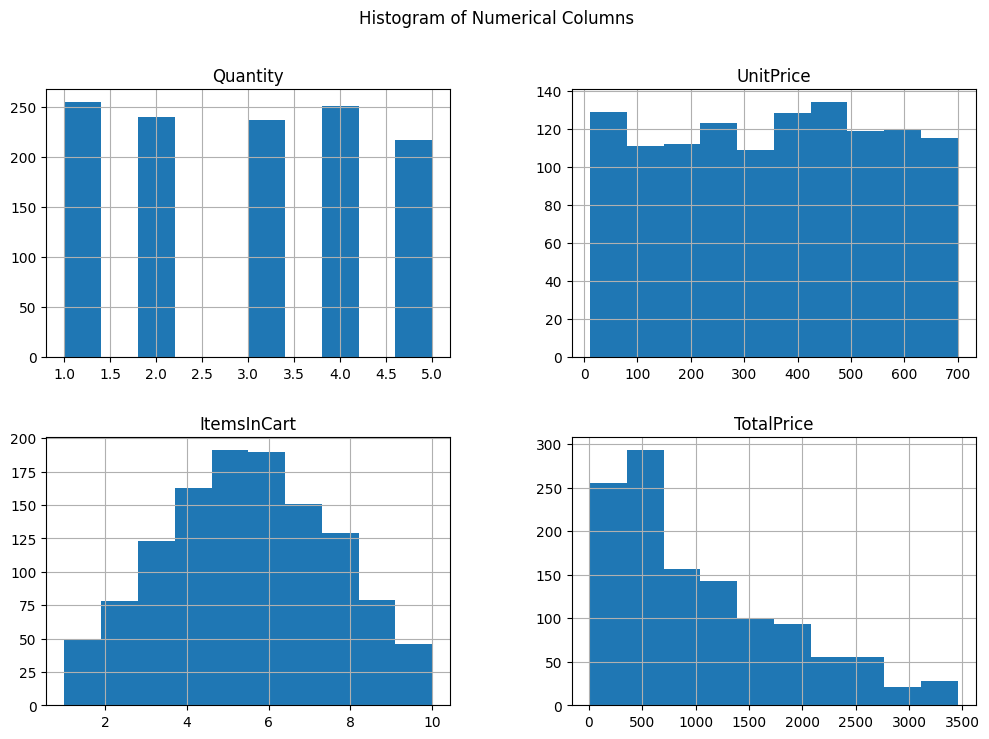

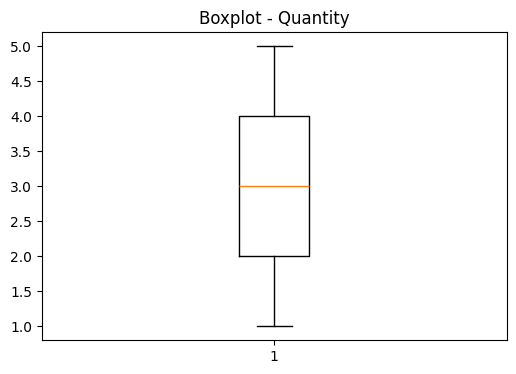

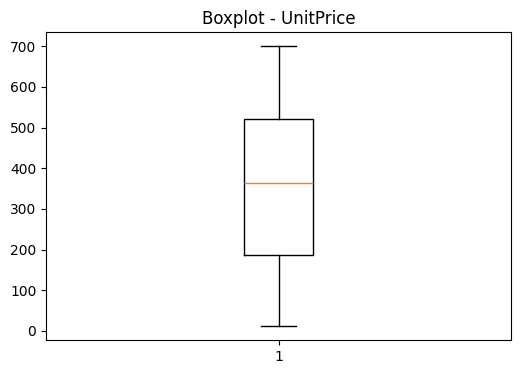

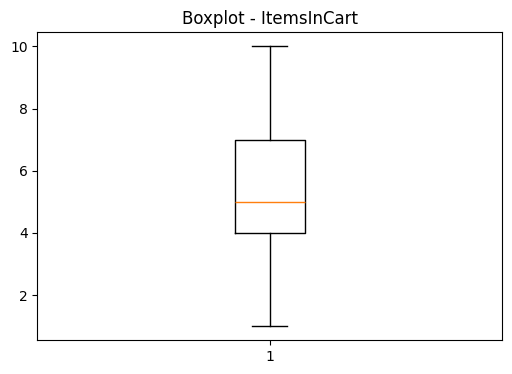

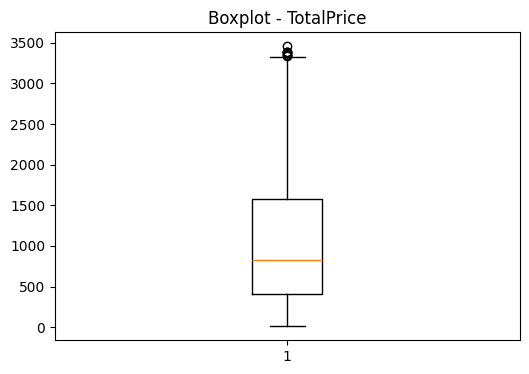

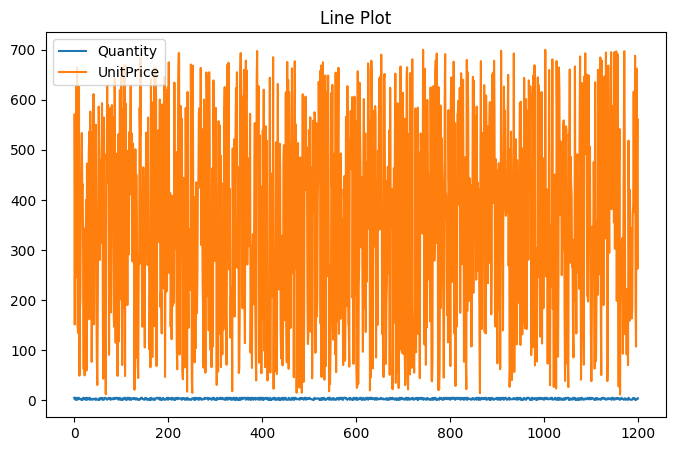

In [9]:
# TASK 4 : DATA VISUALIZATION
print("DATA VISUALIZATION")
# Histogram
df[numeric_cols].hist(figsize=(12, 8))
plt.suptitle("Histogram of Numerical Columns")
plt.show()


# Boxplot
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[col])
    plt.title(f"Boxplot - {col}")
    plt.show()

# Line Plot
if len(numeric_cols) >= 2:
    plt.figure(figsize=(8,5))
    plt.plot(df[numeric_cols[0]], label=numeric_cols[0])
    plt.plot(df[numeric_cols[1]], label=numeric_cols[1])
    plt.legend()
    plt.title("Line Plot")
    plt.show()


TASK 5 : PREDICTIVE MODEL
MAE : 174.34693807740896
R2 Score : -0.0019279935063347686


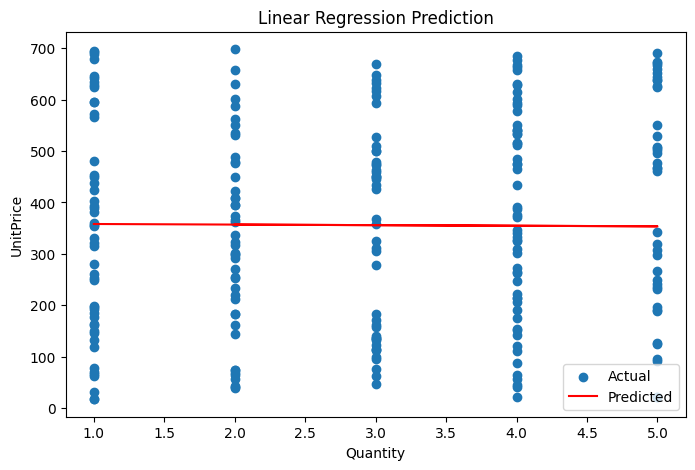

In [12]:
import matplotlib.pyplot as plt

# TASK 5 : PREDICTIVE MODEL
print("TASK 5 : PREDICTIVE MODEL")

if len(numeric_cols) >= 2:

    X = df[[numeric_cols[0]]]
    y = df[numeric_cols[1]]



# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Create Model
model = LinearRegression()

# Train Model
model.fit(X_train, y_train)
# Predict
y_pred = model.predict(X_test)

# Model Evaluation
print("MAE :", mean_absolute_error(y_test, y_pred))
print("R2 Score :", r2_score(y_test, y_pred))

#Plot Prediction
plt.figure(figsize=(8,5))
plt.scatter(X_test, y_test, label="Actual")
plt.plot(X_test, y_pred, color='red', label="Predicted")
plt.xlabel(numeric_cols[0])
plt.ylabel(numeric_cols[1])
plt.title("Linear Regression Prediction")
plt.legend()
plt.show()


The machine learning model was successfully trained and tested using the given dataset. The MAE value showed that the prediction error was low, which means the model was able to give predictions close to the actual values. The R² Score indicated that the model performed well and was able to understand the relationship between the data features effectively.